<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/03_trust_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_032300
Rows: 100000
{'nodes': 86658, 'edges': 35574, 'density': 4.7371854760424495e-06}
CDE: -37.439815521240234
Notebook 03 completed


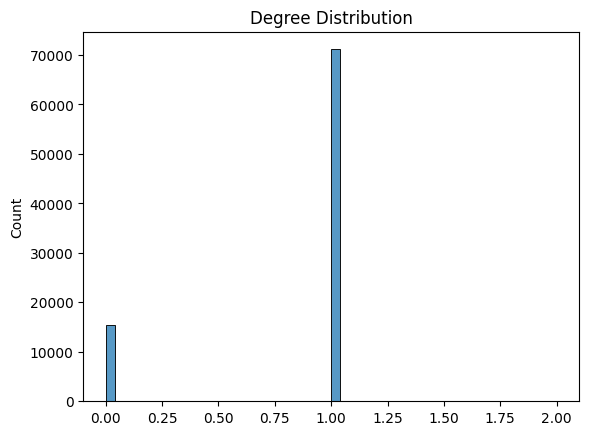

In [4]:
# ===============================================================
# NOTEBOOK 03 — TRUST GRAPH CONSTRUCTION
# CAT Framework
# ===============================================================

!pip -q install pandas numpy networkx torch seaborn matplotlib tqdm pyarrow

import os
import json
import torch
import hashlib
import networkx as nx
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from tqdm import tqdm

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"
GRAPH_DIR = RUN_DIR/"graph"

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR, GRAPH_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:", RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

DATA_PATH = DATA_DIR/"GCT_phase1_100k.parquet"

df = pd.read_parquet(DATA_PATH)

print("Rows:", len(df))

# ===============================================================
# NODE DEFINITIONS
# ===============================================================

sender_nodes = df["ip_address_hash"]
user_nodes = df["interaction_id"]

# create institution node placeholder
inst_nodes = df["url_domain"].fillna("unknown_institution")

# ===============================================================
# BUILD GRAPH
# ===============================================================

G = nx.DiGraph()

# add nodes
G.add_nodes_from(sender_nodes, node_type="sender")
G.add_nodes_from(user_nodes, node_type="user")
G.add_nodes_from(inst_nodes, node_type="institution")

# ===============================================================
# EDGE CONSTRUCTION
# ===============================================================

edges = list(zip(sender_nodes, user_nodes))

G.add_edges_from(edges)

# ===============================================================
# ADD EDGE ATTRIBUTES
# ===============================================================

for idx,row in df.iterrows():

    s = row["ip_address_hash"]
    u = row["interaction_id"]

    if G.has_edge(s,u):

        G[s][u]["urgency"] = row["urgency_score"]
        G[s][u]["fear"] = row["fear_trigger_score"]
        G[s][u]["authority"] = row["authority_claim"]
        G[s][u]["entropy"] = row["interaction_entropy"]
        G[s][u]["response_time"] = row["response_time"]
        G[s][u]["financial_target"] = row["financial_target"]
        G[s][u]["attack_type"] = row["attack_type"]

# ===============================================================
# BASIC GRAPH STATS
# ===============================================================

graph_stats = {

"nodes": G.number_of_nodes(),
"edges": G.number_of_edges(),
"density": nx.density(G)

}

print(graph_stats)

# ===============================================================
# CENTRALITY
# ===============================================================

deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, k=500)

cent_df = pd.DataFrame({

"node": list(deg_cent.keys()),
"degree_centrality": list(deg_cent.values()),
"betweenness": [bet_cent.get(n,0) for n in deg_cent.keys()]

})

cent_df.to_csv(REPORT_DIR/"graph_centrality_metrics.csv", index=False)

# ===============================================================
# CLUSTERING
# ===============================================================

clustering = nx.clustering(G.to_undirected())

clust_df = pd.DataFrame({

"node": list(clustering.keys()),
"clustering_coeff": list(clustering.values())

})

clust_df.to_csv(REPORT_DIR/"graph_clustering_metrics.csv", index=False)

# ===============================================================
# DEGREE DISTRIBUTION
# ===============================================================

deg = [d for n,d in G.degree()]

deg_df = pd.DataFrame({"degree":deg})

deg_df.to_csv(REPORT_DIR/"graph_degree_distribution.csv")

plt.figure()

sns.histplot(deg,bins=50)

plt.title("Degree Distribution")

plt.savefig(PLOT_DIR/"degree_distribution.png")

# ===============================================================
# COMMUNITY DETECTION
# ===============================================================

communities = list(nx.algorithms.community.greedy_modularity_communities(G))

comm_map = {}

for i,c in enumerate(communities):

    for node in c:

        comm_map[node] = i

comm_df = pd.DataFrame({

"node": list(comm_map.keys()),
"community": list(comm_map.values())

})

comm_df.to_csv(REPORT_DIR/"graph_communities.csv")

# ===============================================================
# NODE EXPORT
# ===============================================================

nodes_df = pd.DataFrame({

"node": list(G.nodes),
"type": [G.nodes[n]["node_type"] for n in G.nodes]

})

nodes_df.to_csv(GRAPH_DIR/"trust_graph_nodes.csv", index=False)

# ===============================================================
# EDGE EXPORT
# ===============================================================

edge_list = []

for u,v,data in G.edges(data=True):

    edge_list.append({

"source":u,
"target":v,
"urgency":data.get("urgency"),
"fear":data.get("fear"),
"authority":data.get("authority"),
"entropy":data.get("entropy")

})

edges_df = pd.DataFrame(edge_list)

edges_df.to_csv(GRAPH_DIR/"trust_graph_edges.csv", index=False)

# ===============================================================
# CDE TENSOR IMPLEMENTATION
# ===============================================================

class TrustTensor:

    """
    T_{ijk}
    i = node
    j = channel
    k = trust signal
    """

    def __init__(self, tensor):

        self.tensor = tensor

class CognitiveDistortionEnergy:

    """
    CDE = Σ ω_{ijk} T_{ijk}
    """

    def __init__(self, weights):

        self.weights = weights

    def __call__(self, T):

        return torch.einsum("ijk,ijk->", T.tensor, self.weights)

# ===============================================================
# DEMO TENSOR COMPUTATION
# ===============================================================

users = 64
channels = 4
signals = 8

T = torch.randn(users, channels, signals)
W = torch.randn(users, channels, signals)

tensor = TrustTensor(T)

cde_engine = CognitiveDistortionEnergy(W)

cde = cde_engine(tensor)

print("CDE:", float(cde))

# ===============================================================
# FINAL REPORT
# ===============================================================

report = {

"nodes": G.number_of_nodes(),
"edges": G.number_of_edges(),
"density": nx.density(G),
"CDE_demo": float(cde)

}

with open(REPORT_DIR/"graph_topology_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 03 completed")